# Final Bakery Dataset

This notebook applies the completed manual review decisions, retains positive bakery classes and combines them with the supermarket supplement to create the final set of bakery establishments used in the rest of the project.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

BUSINESS_RAW_FOLDER = Path("../data/business/raw")
BUSINESS_INTERIM_FOLDER = Path("../data/business/interim")
VERIFICATION_FOLDER = (BUSINESS_INTERIM_FOLDER / "ai_verification_v3")
REVIEW_FOLDER = (VERIFICATION_FOLDER / "manual_review_v3")

AI_RESULTS_PATH = (VERIFICATION_FOLDER / "bakery_ai_verification_results.csv")
FALSE_POSITIVE_REVIEW_PATH = (REVIEW_FOLDER / "bakery_manual_review_fp_v3.csv")
FALSE_NEGATIVE_REVIEW_PATH = (REVIEW_FOLDER / "bakery_manual_review_fn_v3.csv")
UNCLEAR_REVIEW_PATH = (REVIEW_FOLDER / "bakery_manual_review_unclear_v3.csv")

EXPECTED_TOTAL = 28847

MULTISTORE_FOLDER = (VERIFICATION_FOLDER / "multistore_location_verification")
MULTISTORE_VERIFICATION_PATH = (MULTISTORE_FOLDER / "bakery_multistore_location_verified.csv")

## Finalising the reviewed bakery classifications

The AI verification results still contain the original classifications, while the three manual review files contain the cases that were checked again afterwards. These decisions are combined so each unique business name has one final classification before returning to the individual FHRS establishments.

In [2]:
def read_review_csv(path):
    try:
        return pd.read_csv(path, keep_default_na=False, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, keep_default_na=False, encoding="cp1252")

fp_review = read_review_csv(FALSE_POSITIVE_REVIEW_PATH)
fn_review = read_review_csv(FALSE_NEGATIVE_REVIEW_PATH)
unclear_review = read_review_csv(UNCLEAR_REVIEW_PATH)

print(f"False-positive reviews: {len(fp_review)}")
print(f"False-negative reviews: {len(fn_review)}")
print(f"Additional unclear reviews: {len(unclear_review)}")

False-positive reviews: 453
False-negative reviews: 131
Additional unclear reviews: 112


In [3]:
fp_review["ReviewSet"] = "FALSE_POSITIVE"
fn_review["ReviewSet"] = "FALSE_NEGATIVE"
unclear_review["ReviewSet"] = "ADDITIONAL_UNCLEAR"

manual_reviews = pd.concat([fp_review, fn_review, unclear_review],
                           ignore_index=True)

valid_classes = {"CORE_BAKERY",
                 "BAKERY_CAFE",
                 "GROCER_BAKERY",
                 "NON_BAKERY",
                 "UNCLEAR"}

missing_manual = (manual_reviews["ManualClass"]
                  .str.strip()
                  .eq(""))

invalid_manual = (set(manual_reviews["ManualClass"]) - valid_classes)

duplicate_reviews = (manual_reviews["BusinessNameClean"]
                     .duplicated()
                     .sum())

print(f"Total review decisions: {len(manual_reviews)}")
print(f"Blank ManualClass values: {missing_manual.sum()}")
print(f"Duplicate reviewed names: {duplicate_reviews}")
print(f"Invalid classes: {invalid_manual}")

if missing_manual.any():
    raise RuntimeError("Some manual reviews are incomplete.")

if invalid_manual:
    raise RuntimeError(f"Invalid ManualClass values found: {invalid_manual}")

if duplicate_reviews:
    raise RuntimeError("A business appears more than once across the review files.")

Total review decisions: 696
Blank ManualClass values: 0
Duplicate reviewed names: 0
Invalid classes: set()


In [4]:
ai_results_raw = pd.read_csv(AI_RESULTS_PATH)

ai_results = (ai_results_raw
              .sort_values("VerificationDateTime")
              .drop_duplicates(subset="BusinessNameClean", keep="last")
              .sort_values("BakeryRank")
              .reset_index(drop=True))

if len(ai_results) != EXPECTED_TOTAL:
    raise RuntimeError(f"Expected {EXPECTED_TOTAL} verified names, but found {len(ai_results)}.")

review_decisions = manual_reviews[["BusinessNameClean",
                                   "ManualClass",
                                   "ManualReason",
                                   "ManualSourceURL",
                                   "ReviewSet"]]

final_classifications = ai_results.merge(review_decisions,
                                         on="BusinessNameClean",
                                         how="left",
                                         validate="one_to_one")

final_classifications["ManualClass"] = (final_classifications["ManualClass"]
                                        .fillna(""))

reviewed = (final_classifications["ManualClass"]
            .str.strip()
            .ne(""))

final_classifications["FinalClass"] = (final_classifications["AIClass"])

final_classifications.loc[reviewed, "FinalClass"
                          ] = final_classifications.loc[reviewed, "ManualClass"]

print(f"Verified business names: {len(final_classifications)}")
print(f"Manual decisions applied: {reviewed.sum()}")

display(final_classifications["FinalClass"]
        .value_counts()
        .rename("Count"))

Verified business names: 28847
Manual decisions applied: 696


FinalClass
NON_BAKERY       20353
UNCLEAR           5590
BAKERY_CAFE       1298
GROCER_BAKERY      996
CORE_BAKERY        610
Name: Count, dtype: int64

# Creating table for report

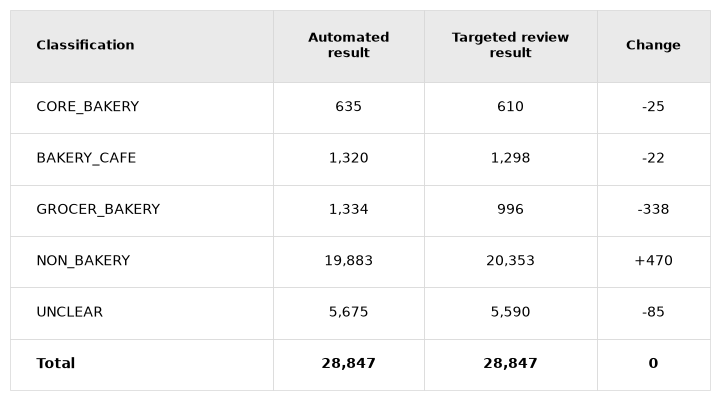

In [5]:
table_classes = ['CORE_BAKERY', 'BAKERY_CAFE', 'GROCER_BAKERY', 'NON_BAKERY', 'UNCLEAR']
table_before = final_classifications['AIClass'].value_counts().reindex(table_classes, fill_value=0)
table_after = final_classifications['FinalClass'].value_counts().reindex(table_classes, fill_value=0)

table_rows = []

for table_label in table_classes:
    table_change = int(table_after[table_label] - table_before[table_label])
    table_rows.append([table_label, f'{table_before[table_label]:,}', f'{table_after[table_label]:,}', f'{table_change:+,}' if table_change else '0'])

table_rows.append(['Total', f'{table_before.sum():,}', f'{table_after.sum():,}', '0'])

table_5_2 = pd.DataFrame(table_rows, columns=['Classification', 'Automated\nresult', 'Targeted review\nresult', 'Change'])

table_height = 0.8 + 0.5 * len(table_5_2)
table_fig = plt.figure(figsize=(7, table_height), facecolor="white")
table_ax = table_fig.add_axes([0, 0, 1, 1])
table_ax.axis("off")

table_plot = table_ax.table(cellText=table_5_2.values,
                            colLabels=table_5_2.columns,
                            colWidths=[0.35, 0.20, 0.23, 0.15],
                            cellLoc="center",
                            bbox=[0, 0, 1, 1])

table_plot.auto_set_font_size(False)
table_plot.set_fontsize(10)

for (table_row, table_col), table_cell in table_plot.get_celld().items():
    table_cell.set_facecolor("white")
    table_cell.set_edgecolor("#D5D5D5")
    table_cell.set_linewidth(0.5)
    table_cell.set_height(0.5 / table_height)
    table_cell.set_text_props(color="black", fontfamily="DejaVu Sans")

    if table_row == 0:
        table_cell.set_facecolor("#EAEAEA")
        table_cell.set_height(0.7 / table_height)
        table_cell.set_text_props(weight="bold", fontsize=9)

    if table_col == 0:
        table_cell.set_text_props(ha="left")

    if table_row == len(table_5_2):
        table_cell.set_text_props(weight="bold")

# Save a sharp PNG and display it in the notebook.
table_folder = Path("../outputs/figures/chapter5_tables")
table_folder.mkdir(parents=True, exist_ok=True)
table_fig.savefig(table_folder / "table_5_2.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
plt.show()
plt.close(table_fig)

In [9]:
review_positive_classes = ["CORE_BAKERY",
                           "BAKERY_CAFE",
                           "GROCER_BAKERY"]

ai_positive = final_classifications["AIClass"].isin(review_positive_classes)
final_positive = final_classifications["FinalClass"].isin(review_positive_classes)

in_to_out = (ai_positive & ~final_positive).sum()
out_to_in = (~ai_positive & final_positive).sum()

positive_to_positive = (ai_positive & final_positive)

positive_class_changes = (positive_to_positive & final_classifications["AIClass"]
                          .ne(final_classifications["FinalClass"])).sum()

print(f"AI positive names: {ai_positive.sum()}")
print(f"Final positive names: {final_positive.sum()}")
print(f"Moved from bakery to non-bakery/unclear: {in_to_out}")
print(f"Moved from non-bakery/unclear to bakery: {out_to_in}")
print(f"Changed between positive bakery classes: {positive_class_changes}")

display(pd.crosstab(final_classifications.loc[positive_to_positive, "AIClass"],
                    final_classifications.loc[positive_to_positive, "FinalClass"],
                    rownames=["AI class"],
                    colnames=["Final reviewed class"]))

AI positive names: 3289
Final positive names: 2904
Moved from bakery to non-bakery/unclear: 417
Moved from non-bakery/unclear to bakery: 32
Changed between positive bakery classes: 0


Final reviewed class,BAKERY_CAFE,CORE_BAKERY,GROCER_BAKERY
AI class,,,
BAKERY_CAFE,1277,0,0
CORE_BAKERY,0,602,0
GROCER_BAKERY,0,0,993


# Building final classifications on the FHRS establishments

The final name-level classifications are applied to the FHRS establishments first. For the additional multi-store branches checked in notebook 09b, the location-specific classification then replaces the representative name-level classification.

In [10]:
FHRS_DATA_DATE = "2026-07-23"
EXPECTED_FHRS_ROWS = 81080
RANKED_FHRS_PATH = (BUSINESS_INTERIM_FOLDER / f"london_fhrs_ranked_establishments_{FHRS_DATA_DATE}.csv")
RAW_FHRS_PATH = (BUSINESS_RAW_FOLDER/ f"london_fhrs_raw_{FHRS_DATA_DATE}.csv")

SUPERMARKET_FOLDER = (BUSINESS_INTERIM_FOLDER / "supermarket_bakery")
SUPERMARKET_PATH = (SUPERMARKET_FOLDER / "supermarket_bakery_final.csv")

FINAL_FOLDER = Path("../data/business/processed")
FINAL_FOLDER.mkdir(parents=True, exist_ok=True)

FINAL_CLASSIFICATIONS_PATH = (FINAL_FOLDER / "bakery_name_classifications_final.csv")

FINAL_BAKERY_PATH = (FINAL_FOLDER / f"london_bakery_establishments_final_{FHRS_DATA_DATE}.csv")

In [11]:
final_classifications.to_csv(FINAL_CLASSIFICATIONS_PATH, index=False, encoding="utf-8-sig")

print(f"Saved final name classifications to: {FINAL_CLASSIFICATIONS_PATH}")

Saved final name classifications to: ..\data\business\processed\bakery_name_classifications_final.csv


In [12]:
positive_classes = {"CORE_BAKERY",
                    "BAKERY_CAFE",
                    "GROCER_BAKERY"}

# Load the full FHRS establishment data
fhrs_ranked = pd.read_csv(RANKED_FHRS_PATH, low_memory=False)

fhrs_ranked["FHRSID"] = (pd.to_numeric(fhrs_ranked["FHRSID"], errors="coerce")
                         .astype("Int64"))

print(f"FHRS rows loaded: {len(fhrs_ranked)}")

if len(fhrs_ranked) != EXPECTED_FHRS_ROWS:
    raise RuntimeError(f"Expected {EXPECTED_FHRS_ROWS} FHRS rows, but found {len(fhrs_ranked)}.")

if fhrs_ranked["FHRSID"].duplicated().any():
    raise RuntimeError("Duplicate FHRSID values found in the FHRS dataset.")

# Assemble the complete address
address_columns = ["FHRSID",
                   "AddressLine1",
                   "AddressLine2",
                   "AddressLine3",
                   "AddressLine4"]

fhrs_addresses = pd.read_csv(RAW_FHRS_PATH, usecols=address_columns, low_memory=False)

fhrs_addresses["FHRSID"] = (pd.to_numeric(fhrs_addresses["FHRSID"], errors="coerce")
                            .astype("Int64"))

fhrs_addresses = (fhrs_addresses
                  .drop_duplicates(subset="FHRSID", keep="first"))

address_parts = ["AddressLine1",
                 "AddressLine2",
                 "AddressLine3",
                 "AddressLine4"]

fhrs_addresses["Address"] = (fhrs_addresses[address_parts]
                             .fillna("")
                             .astype(str)
                             .apply(lambda row: ", ".join(value.strip()
                                                          for value in row
                                                          if value.strip()),
                                                          axis=1))

fhrs_addresses = (fhrs_addresses[["FHRSID", "Address"]])

fhrs_ranked = fhrs_ranked.merge(fhrs_addresses,
                                on="FHRSID",
                                how="left",
                                validate="one_to_one")

print("FHRS establishments with an address:",
      fhrs_ranked["Address"]
      .fillna("")
      .str.strip()
      .ne("")
      .sum())


# Apply the final name-level classifications
name_labels = (final_classifications[["BusinessNameClean", "FinalClass"]])

fhrs_with_labels = fhrs_ranked.merge(name_labels,
                                     on="BusinessNameClean",
                                     how="left",
                                     validate="many_to_one")

fhrs_with_labels["ClassificationSource"] = "VERIFIED_CANDIDATE"

# Load the location-specific multi-store decisions
multistore_results = pd.read_csv(MULTISTORE_VERIFICATION_PATH, low_memory=False)

multistore_results["FHRSID"] = (pd.to_numeric(multistore_results["FHRSID"],
                                              errors="coerce")
                                              .astype("Int64"))

location_labels = (multistore_results[["FHRSID", "AIClass"]]
                   .rename(columns={"AIClass": "LocationClass"}))

fhrs_with_labels = (fhrs_with_labels.merge(location_labels,
                                           on="FHRSID",
                                           how="left",
                                           validate="one_to_one"))

location_checked = (fhrs_with_labels["LocationClass"].notna())

# Replace the representative name classification with the location-specific result
fhrs_with_labels.loc[location_checked, "FinalClass"
                     ] = fhrs_with_labels.loc[location_checked, "LocationClass"]

fhrs_with_labels.loc[location_checked, "ClassificationSource"
                     ] = "LOCATION_VERIFICATION"

# Retain only positive bakery establishments
main_bakeries = (fhrs_with_labels[fhrs_with_labels["FinalClass"]
                                  .isin(positive_classes)].copy())

positive_names = (final_classifications["FinalClass"]
                  .isin(positive_classes)
                  .sum())

print(f"Positive unique business names: {positive_names}")
print(f"Location-level decisions applied: {location_checked.sum()}")
print(f"Positive FHRS establishments: {len(main_bakeries)}")

display(main_bakeries["FinalClass"]
        .value_counts()
        .rename("Establishments"))

display(main_bakeries["ClassificationSource"]
        .value_counts()
        .rename("Establishments"))

FHRS rows loaded: 81080
FHRS establishments with an address: 71526
Positive unique business names: 2904
Location-level decisions applied: 6452
Positive FHRS establishments: 4928


FinalClass
BAKERY_CAFE      2021
GROCER_BAKERY    1960
CORE_BAKERY       947
Name: Establishments, dtype: int64

ClassificationSource
VERIFIED_CANDIDATE       2904
LOCATION_VERIFICATION    2024
Name: Establishments, dtype: int64

# Adding on suplementary supermarket data

In [13]:
supermarket_bakeries = pd.read_csv(SUPERMARKET_PATH, low_memory=False)

if "FHRSID" not in supermarket_bakeries.columns:
    raise RuntimeError("FHRSID is missing from the supermarket dataset.")

if supermarket_bakeries["FHRSID"].duplicated().any():
    raise RuntimeError("Duplicate FHRSID values found in the supermarket dataset.")

main_ids = set(main_bakeries["FHRSID"])
supermarket_ids = set(supermarket_bakeries["FHRSID"])
fhrs_ids = set(fhrs_ranked["FHRSID"])

missing_supermarket_ids = (supermarket_ids - fhrs_ids)

if missing_supermarket_ids:
    raise RuntimeError(f"{len(missing_supermarket_ids)} supermarket locations were not found in the FHRS dataset.")

overlap_ids = (supermarket_ids & main_ids)

new_supermarket_ids = (supermarket_ids - main_ids)

supplement_bakeries = (fhrs_ranked[fhrs_ranked["FHRSID"]
                                   .isin(new_supermarket_ids)].copy())

supplement_bakeries["FinalClass"] = ("GROCER_BAKERY")
supplement_bakeries["ClassificationSource"] = ("SUPERMARKET_SUPPLEMENT")

print(f"Supermarket bakery locations: {len(supermarket_bakeries)}")
print(f"Already included in main dataset: {len(overlap_ids)}")
print(f"Additional supermarket locations: {len(supplement_bakeries)}")

Supermarket bakery locations: 749
Already included in main dataset: 456
Additional supermarket locations: 293


# Final bakery dataset

In [14]:
final_bakeries = pd.concat([main_bakeries, supplement_bakeries],
                           ignore_index=True)

duplicate_ids = (final_bakeries["FHRSID"]
                 .duplicated()
                 .sum())

if duplicate_ids:
    raise RuntimeError(f"{duplicate_ids} duplicate FHRS IDs remain in the final bakery dataset.")

invalid_classes = (set(final_bakeries["FinalClass"]) - positive_classes)

if invalid_classes:
    raise RuntimeError(f"Unexpected final classes found: {invalid_classes}")

print(f"Final bakery establishments: {len(final_bakeries)}")

display(final_bakeries["FinalClass"]
        .value_counts()
        .rename("Establishments"))

display(final_bakeries["ClassificationSource"]
        .value_counts()
        .rename("Establishments"))

Final bakery establishments: 5221


FinalClass
GROCER_BAKERY    2253
BAKERY_CAFE      2021
CORE_BAKERY       947
Name: Establishments, dtype: int64

ClassificationSource
VERIFIED_CANDIDATE        2904
LOCATION_VERIFICATION     2024
SUPERMARKET_SUPPLEMENT     293
Name: Establishments, dtype: int64

Checking location data on final bakery dataset

In [15]:
has_address = (final_bakeries["Address"]
               .fillna("")
               .astype(str)
               .str.strip()
               .ne(""))

has_postcode = (final_bakeries["PostCode"]
                .fillna("")
                .astype(str)
                .str.strip()
                .ne(""))

has_coordinates = (final_bakeries["geocode.longitude"].notna()
                   & final_bakeries["geocode.latitude"].notna())

no_location_information = (~has_address & ~has_postcode & ~has_coordinates)
address_to_postcode = (~has_postcode & ~has_coordinates & has_address)

print(f"Missing address: {(~has_address).sum()}")

print(f"Missing postcode: {(~has_postcode).sum()}")

print(f"Missing coordinates: {(~has_coordinates).sum()}")

print(f"Postcode needs to be recovered using address: {address_to_postcode.sum()}")

print(f"Neither address, postcode or coordinates: {no_location_information.sum()}")

Missing address: 39
Missing postcode: 51
Missing coordinates: 282
Postcode needs to be recovered using address: 16
Neither address, postcode or coordinates: 0


In [16]:
display(final_bakeries.loc[address_to_postcode,
                           ["FHRSID",
                            "BusinessName",
                            "BusinessNameClean",
                            "Address",
                            "PostCode",
                            "LocalAuthorityName",
                            "FinalClass",
                            "ClassificationSource"]])

,FHRSID,BusinessName,BusinessNameClean,Address,PostCode,LocalAuthorityName,FinalClass,ClassificationSource
695,1572098,Daily Fresh Naan Ltd,daily fresh naan ltd,"To Go 176 Upper Tooting Road, London, Wandsworth",NaN,Wandsworth,CORE_BAKERY,VERIFIED_CANDIDATE
1088,1574924,Company of Cooks by Compass Group UK,company of cooks by compass group uk,"Hampton Court Palace Hampton Court Road, Hampt...",NaN,Richmond-Upon-Thames,BAKERY_CAFE,LOCATION_VERIFICATION
1353,1704723,Greggs,greggs,"Erith Shopping Centre, Erith High Street, Erit...",NaN,Bexley,CORE_BAKERY,LOCATION_VERIFICATION
1821,505278,Waitrose Ltd,waitrose ltd,"Street Record Alexandra Road, Wimbledon, Merton",NaN,Merton,GROCER_BAKERY,LOCATION_VERIFICATION
1827,1571636,Waitrose Ltd,waitrose ltd,"77 - 83 Upper Richmond Road, London, Wandsworth",NaN,Wandsworth,GROCER_BAKERY,LOCATION_VERIFICATION
1834,1888937,Bagel Town,bagel town,"Level 1 Lower The Exchange, High Road, Ilford",NaN,Redbridge,BAKERY_CAFE,LOCATION_VERIFICATION
1977,1635361,Muffin Break,muffin break,"Muffin Break, Food Court Retail Area, The Whit...",NaN,Islington,BAKERY_CAFE,LOCATION_VERIFICATION
1990,1857086,Little Julie's,little julie s,"102 Portland Road, LONDON",NaN,Kensington and Chelsea,BAKERY_CAFE,VERIFIED_CANDIDATE
2438,1574329,Sainsbury's,sainsbury s,"11 Barnes High Street, Barnes, London, Richmon...",NaN,Richmond-Upon-Thames,GROCER_BAKERY,LOCATION_VERIFICATION
2547,411632,Fortnum & Mason,fortnum and mason,"181-186 PICCADILLY, LONDON",NaN,Westminster,GROCER_BAKERY,VERIFIED_CANDIDATE


Since it's such a small number of locations, these corrections wll be done manually instead of using geopy lookups.

In [17]:
postcode_corrections = {1574924: "KT8 9AU",
                        1572098: "SW17 7ER",
                        1704723: "DA8 1TA",
                        505278: "SW19 7JY",
                        1571636: "SW15 2TD",
                        1888937: "IG1 1AS",
                        1635361: "N19 5NF",
                        1857086: "W11 4LX",
                        1574329: "SW13 9LW",
                        411632:	"W1A 1ER",
                        1574361: "TW12 1NY",
                        1572372: "SW11 2AS",
                        1688110: "N5 2NL",
                        1574249: "TW2 5NT",
                        1712470: "SW19 4JS",
                        416999: "EC1Y 8NX"}

for fhrsid, postcode in postcode_corrections.items():
    final_bakeries.loc[final_bakeries["FHRSID"].eq(fhrsid), "PostCode"] = postcode

missing_postcode_and_coords = (final_bakeries["PostCode"].fillna("").str.strip().eq("")
                               & final_bakeries["geocode.longitude"].isna()
                               & final_bakeries["geocode.latitude"].isna())

print(f"Still missing postcode and coordinates: {missing_postcode_and_coords.sum()}")

Still missing postcode and coordinates: 0


In [18]:
has_postcode = (final_bakeries["PostCode"]
                .fillna("")
                .astype(str)
                .str.strip()
                .ne(""))

has_coordinates = (final_bakeries["geocode.longitude"].notna()
                   & final_bakeries["geocode.latitude"].notna())

unresolved_location = (~has_postcode & ~has_coordinates)

print(f"Final bakery establishments: {len(final_bakeries)}")
print(f"Missing postcode: {(~has_postcode).sum()}")
print(f"Missing coordinates: {(~has_coordinates).sum()}")
print(f"Neither postcode nor coordinates: {unresolved_location.sum()}")

display(final_bakeries["ClassificationSource"].value_counts(dropna=False))

Final bakery establishments: 5221
Missing postcode: 35
Missing coordinates: 282
Neither postcode nor coordinates: 0


ClassificationSource
VERIFIED_CANDIDATE        2904
LOCATION_VERIFICATION     2024
SUPERMARKET_SUPPLEMENT     293
Name: count, dtype: int64

In [19]:
if final_bakeries["FHRSID"].duplicated().any():
    raise RuntimeError("Duplicate FHRSID values remain in final bakery dataset.")

if final_bakeries["FHRSID"].isna().any():
    raise RuntimeError("Missing FHRSID values found in final bakery dataset.")

valid_final_classes = {"CORE_BAKERY",
                       "BAKERY_CAFE",
                       "GROCER_BAKERY"}

invalid_classes = (set(final_bakeries["FinalClass"]) - valid_final_classes)

if invalid_classes:
    raise RuntimeError(f"Unexpected FinalClass values: {invalid_classes}")

valid_sources = {"VERIFIED_CANDIDATE",
                 "LOCATION_VERIFICATION",
                 "SUPERMARKET_SUPPLEMENT"}

invalid_sources = (set(final_bakeries["ClassificationSource"]) - valid_sources)

if invalid_sources:
    raise RuntimeError(f"Unexpected ClassificationSource values: {invalid_sources}")

print("Final bakery dataset validation passed.")

Final bakery dataset validation passed.


In [20]:
final_columns = ["FHRSID",
                 "BusinessName",
                 "BusinessNameClean",
                 "BusinessType",
                 "Address",
                 "PostCode",
                 "LocalAuthorityName",
                 "geocode.longitude",
                 "geocode.latitude",
                 "FinalClass",
                 "ClassificationSource"]

final_bakeries = (final_bakeries[final_columns]
                  .sort_values(["LocalAuthorityName",
                                "PostCode",
                                "BusinessName"],
                                na_position="last")
                  .reset_index(drop=True))

final_bakeries.to_csv(FINAL_BAKERY_PATH, index=False, encoding="utf-8-sig")

print(f"Saved final bakery dataset to: {FINAL_BAKERY_PATH}")

print(f"Final establishment count: {len(final_bakeries)}")

display(final_bakeries["FinalClass"]
        .value_counts()
        .rename("Establishments"))

Saved final bakery dataset to: ..\data\business\processed\london_bakery_establishments_final_2026-07-23.csv
Final establishment count: 5221


FinalClass
GROCER_BAKERY    2253
BAKERY_CAFE      2021
CORE_BAKERY       947
Name: Establishments, dtype: int64

## Composition of the final bakery dataset

The final dataset contains three types of identified bakery provision:
- core bakeries
- bakery cafés
- grocer and supermarket bakeries

The composition of the final dataset is shown below.

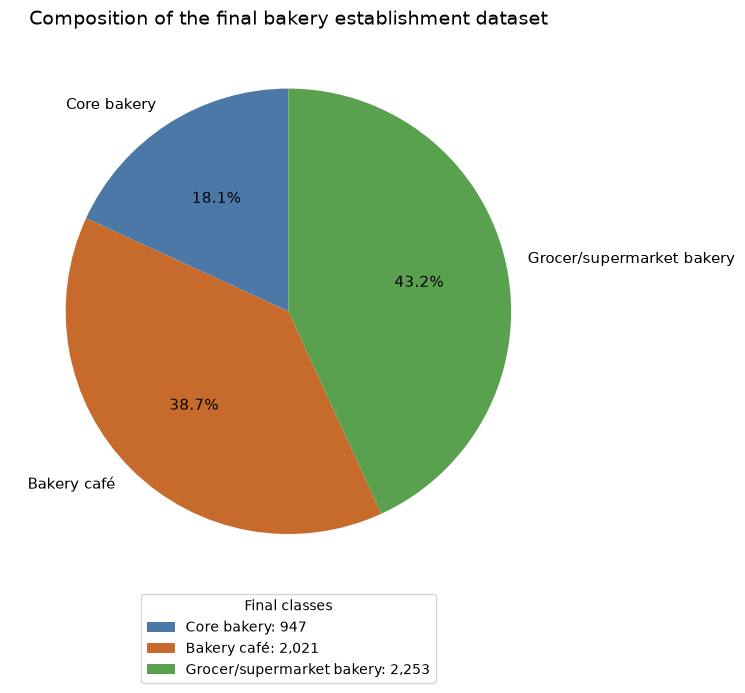

Final class
CORE_BAKERY       947
BAKERY_CAFE      2021
GROCER_BAKERY    2253
Name: Establishments, dtype: int64

Saved to: ..\outputs\figures\final_bakery_class_composition_2026-07-23.png


In [21]:
FIGURE_FOLDER = Path("../outputs/figures")
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

class_order = ["CORE_BAKERY",
               "BAKERY_CAFE",
               "GROCER_BAKERY"]

class_labels = ["Core bakery",
                "Bakery café",
                "Grocer/supermarket bakery"]

class_colours = ["#4c78a8", "#c66b2b", "#59a14f"]

class_counts = (final_bakeries["FinalClass"]
                .value_counts()
                .reindex(class_order))

legend_labels = [f"{label}: {count:,}" 
                 for label, count in zip(class_labels, class_counts)]

fig, axis = plt.subplots(figsize=(9, 7))

wedges, texts, percentages = axis.pie(class_counts,
                                      labels=class_labels,
                                      colors=class_colours,
                                      autopct="%1.1f%%",
                                      startangle=90,
                                      textprops={"fontsize": 11})

axis.legend(wedges,
            legend_labels,
            title="Final classes",
            loc="lower center",
            bbox_to_anchor=(0.5, -0.18),
            ncol=1)

axis.set_title("Composition of the final bakery establishment dataset", fontsize=14)

plt.tight_layout()

CLASS_COMPOSITION_PATH = (FIGURE_FOLDER / f"final_bakery_class_composition_{FHRS_DATA_DATE}.png")
plt.savefig(CLASS_COMPOSITION_PATH, dpi=300, bbox_inches="tight")
plt.show()

display(class_counts
        .rename_axis("Final class")
        .rename("Establishments"))

print(f"Saved to: {CLASS_COMPOSITION_PATH}")

## Random validation sample

A random stratified sample of 150 final establishments are taken (50 from each class) without their assigned classification to give an indication of the effectiveness of the classification pipeline

In [ ]:
FINAL_VALIDATION_FOLDER = (REVIEW_FOLDER / "final_validation")
FINAL_VALIDATION_FOLDER.mkdir(parents=True, exist_ok=True)

VALIDATION_SAMPLE_PATH = (FINAL_VALIDATION_FOLDER / "final_bakery_validation_sample.csv")

sample_settings = {"CORE_BAKERY": 17,
                   "BAKERY_CAFE": 27,
                   "GROCER_BAKERY": 37}

TARGET_PER_CLASS = 50

if VALIDATION_SAMPLE_PATH.exists():

    validation_sample = read_review_csv(VALIDATION_SAMPLE_PATH)
    print("Loaded the existing validation sample without changing it.")

else:
    sample_parts = []

    for final_class, random_seed in sample_settings.items():
        class_sample = (final_bakeries[final_bakeries["FinalClass"] == final_class]
                        .sample(n=TARGET_PER_CLASS, random_state=random_seed))

        sample_parts.append(class_sample)

    validation_sample = pd.concat(sample_parts, ignore_index=True)

    validation_sample = (validation_sample
                         .sample(frac=1, random_state=42)
                         .reset_index(drop=True))

    validation_sample.insert(0, "SampleNumber", range(1, len(validation_sample) + 1))

    validation_sample["ManualClass"] = ""
    validation_sample["EvidenceURL"] = ""
    validation_sample["ReviewNotes"] = ""

    review_columns = ["SampleNumber",
                      "FHRSID",
                      "BusinessName",
                      "Address",
                      "PostCode",
                      "LocalAuthorityName",
                      "ManualClass",
                      "EvidenceURL",
                      "ReviewNotes"]

    validation_sample = validation_sample[review_columns]

    validation_sample.to_csv(VALIDATION_SAMPLE_PATH, index=False, encoding="utf-8-sig")

print(f"Validation rows: {len(validation_sample)}")

The validation sample already exists and has not been overwritten.
Validation rows: 150


# Evaluation post-review

In [23]:
validation_review = read_review_csv(VALIDATION_SAMPLE_PATH)

validation_review["ManualClass"] = (validation_review["ManualClass"]
                                    .str.strip()
                                    .str.upper())

completed_reviews = (validation_review["ManualClass"].ne(""))

print(f"Completed reviews: {completed_reviews.sum()} / 150")

valid_review_classes = {"CORE_BAKERY",
                        "BAKERY_CAFE",
                        "GROCER_BAKERY",
                        "NON_BAKERY",
                        "UNCLEAR"}

entered_classes = set(validation_review.loc[ completed_reviews, "ManualClass"])

invalid_classes = (entered_classes - valid_review_classes)

if invalid_classes:
    raise RuntimeError(f"Invalid manual classes found: {invalid_classes}")

if completed_reviews.sum() < 150:
    print("Complete the remaining manual reviews before calculating the final results.")

else:
    validation_results = validation_review.merge(
        final_bakeries[["FHRSID",
                        "FinalClass",
                        "ClassificationSource"]],
                        on="FHRSID",
                        how="left",
                        validate="one_to_one")

    positive_classes = {"CORE_BAKERY", "BAKERY_CAFE", "GROCER_BAKERY"}

    validation_results["ExactClassCorrect"
                       ] = (validation_results["ManualClass"] == validation_results["FinalClass"])

    validation_results["BakeryInclusionCorrect"
                       ] = (validation_results["ManualClass"]
                            .isin(positive_classes))

    exact_accuracy = (validation_results["ExactClassCorrect"]
                      .mean() * 100)

    inclusion_accuracy = (validation_results["BakeryInclusionCorrect"]
                          .mean() * 100)

    print(f"Correct exact classifications: {validation_results['ExactClassCorrect'].sum()} / 150")

    print(f"Exact classification agreement: {exact_accuracy:.1f}%")

    print(f"Correctly included as bakery provision: {validation_results['BakeryInclusionCorrect'].sum()} / 150")

    print(f"Bakery inclusion agreement: {inclusion_accuracy:.1f}%")

Completed reviews: 150 / 150
Correct exact classifications: 90 / 150
Exact classification agreement: 60.0%
Correctly included as bakery provision: 110 / 150
Bakery inclusion agreement: 73.3%


In [24]:
if completed_reviews.sum() == 150:
    validation_by_class = (validation_results
                           .groupby("FinalClass")
                           .agg(Reviewed=("FHRSID", "count"),
                                Exact_correct=("ExactClassCorrect", "sum"),
                                Inclusion_correct=("BakeryInclusionCorrect", "sum"))
                            .reset_index())

    validation_by_class["Exact agreement (%)"
                        ] = (validation_by_class["Exact_correct"] / validation_by_class["Reviewed"] * 100)

    validation_by_class["Inclusion agreement (%)"
                        ] = (validation_by_class["Inclusion_correct"] / validation_by_class["Reviewed"] * 100)

    display(validation_by_class.round({"Exact agreement (%)": 1,
                                       "Inclusion agreement (%)": 1}))

    confusion_table = pd.crosstab(validation_results["FinalClass"], validation_results["ManualClass"],
                                   rownames=["Final class"], colnames=["Manual class"])

    print("Comparison of final and manual classifications")

    display(confusion_table)

,FinalClass,Reviewed,Exact_correct,Inclusion_correct,Exact agreement (%),Inclusion agreement (%)
0,BAKERY_CAFE,50,32,43,64.0,86.0
1,CORE_BAKERY,50,42,47,84.0,94.0
2,GROCER_BAKERY,50,16,20,32.0,40.0


Comparison of final and manual classifications


Manual class,BAKERY_CAFE,CORE_BAKERY,GROCER_BAKERY,NON_BAKERY,UNCLEAR
Final class,,,,,
BAKERY_CAFE,32,11,0,6,1
CORE_BAKERY,4,42,1,1,2
GROCER_BAKERY,2,2,16,23,7


# Create table for report

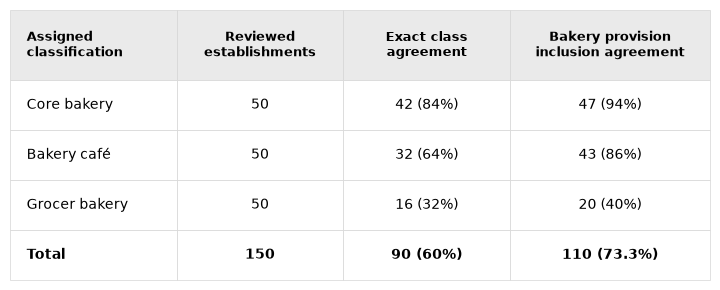

In [25]:
table_classes = ['CORE_BAKERY', 'BAKERY_CAFE', 'GROCER_BAKERY']
table_labels = ['Core bakery', 'Bakery café', 'Grocer bakery']

table_audit = validation_by_class.set_index('FinalClass').loc[table_classes, 
                                                              ['Reviewed', 'Exact_correct', 'Inclusion_correct']].copy()

assert table_audit['Reviewed'].eq(50).all(), 'Complete all 50 reviews per class first.'
table_audit.loc['Total'] = table_audit.sum()

table_rows = []

for table_label, (table__, table_result) in zip(table_labels + ['Total'], table_audit.iterrows()):

    table_n = int(table_result['Reviewed'])
    table_exact = int(table_result['Exact_correct'])
    table_included = int(table_result['Inclusion_correct'])
    table_exact_pct = f'{table_exact / table_n * 100:.1f}'.removesuffix('.0')
    table_included_pct = f'{table_included / table_n * 100:.1f}'.removesuffix('.0')
    table_rows.append([table_label, 
                       str(table_n), 
                       f'{table_exact} ({table_exact_pct}%)', 
                       f'{table_included} ({table_included_pct}%)'])

table_5_4 = pd.DataFrame(table_rows, columns=['Assigned\nclassification', 'Reviewed\nestablishments', 'Exact class\nagreement', 'Bakery provision\ninclusion agreement'])

table_height = 0.7 + 0.5 * len(table_5_4)
table_fig = plt.figure(figsize=(7, table_height), facecolor="white")
table_ax = table_fig.add_axes([0, 0, 1, 1])
table_ax.axis("off")

table_plot = table_ax.table(
    cellText=table_5_4.values,
    colLabels=table_5_4.columns,
    colWidths=[0.25, 0.25, 0.25, 0.30],
    cellLoc="center",
    bbox=[0, 0, 1, 1])

table_plot.auto_set_font_size(False)
table_plot.set_fontsize(10)

for (table_row, table_col), table_cell in table_plot.get_celld().items():

    table_cell.set_facecolor("white")
    table_cell.set_edgecolor("#D5D5D5")
    table_cell.set_linewidth(0.5)
    table_cell.set_height(0.5 / table_height)
    table_cell.set_text_props(color="black", fontfamily="DejaVu Sans")

    if table_row == 0:
        table_cell.set_facecolor("#EAEAEA")
        table_cell.set_height(0.7 / table_height)
        table_cell.set_text_props(weight="bold", fontsize=9)

    if table_col == 0:
        table_cell.set_text_props(ha="left")

    if table_row == len(table_5_4):
        table_cell.set_text_props(weight="bold")

table_folder = Path("../outputs/figures/chapter5_tables")
table_folder.mkdir(parents=True, exist_ok=True)

table_fig.savefig(table_folder / "table_5_4.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
plt.show()
plt.close(table_fig)


In [26]:
if completed_reviews.sum() == 150:
    VALIDATION_RESULTS_PATH = (FINAL_VALIDATION_FOLDER  / "final_bakery_validation_results.csv")

    TABLE_FOLDER = Path("../outputs/tables")
    TABLE_FOLDER.mkdir(parents=True, exist_ok=True)
    
    VALIDATION_SUMMARY_PATH = (TABLE_FOLDER / f"final_bakery_validation_summary_{FHRS_DATA_DATE}.csv")

    validation_results.to_csv(VALIDATION_RESULTS_PATH, index=False, encoding="utf-8-sig")
    validation_by_class.to_csv(VALIDATION_SUMMARY_PATH, index=False, encoding="utf-8-sig")

    print(f"Completed validation results saved to: {VALIDATION_RESULTS_PATH}")
    print(f"Validation summary saved to: {VALIDATION_SUMMARY_PATH}")

Completed validation results saved to: ..\data\business\interim\ai_verification_v3\manual_review_v3\final_validation\final_bakery_validation_results.csv
Validation summary saved to: ..\outputs\tables\final_bakery_validation_summary_2026-07-23.csv
